In [2]:
import pandas as pd
pd.__version__


'3.0.6'

In [3]:
df = pd.read_csv("../data/credit_risk_dataset.csv")
df.shape

(32581, 12)

In [10]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
pd.read_csv

<function pandas.read_csv(filepath_or_buffer: 'FilePath | ReadCsvBuffer[bytes] | ReadCsvBuffer[str]', *, sep: 'str | None | lib.NoDefault' = <no_default>, delimiter: 'str | None | lib.NoDefault' = None, header: "int | Sequence[int] | None | Literal['infer']" = 'infer', names: 'Sequence[Hashable] | None | lib.NoDefault' = <no_default>, index_col: 'IndexLabel | Literal[False] | None' = None, usecols: 'UsecolsArgType' = None, dtype: 'DtypeArg | None' = None, engine: 'CSVEngine | None' = None, converters: 'Mapping[HashableT, Callable] | None' = None, true_values: 'list | None' = None, false_values: 'list | None' = None, skipinitialspace: 'bool' = False, skiprows: 'list[int] | int | Callable[[Hashable], bool] | None' = None, skipfooter: 'int' = 0, nrows: 'int | None' = None, na_values: 'Hashable | Iterable[Hashable] | Mapping[Hashable, Iterable[Hashable]] | None' = None, keep_default_na: 'bool' = True, na_filter: 'bool' = True, skip_blank_lines: 'bool' = True, parse_dates: 'bool | Sequence[

In [15]:
len(df)


32581

In [18]:
Default_rate=(df['loan_status']==1).sum()/len(df)
print(Default_rate)

0.21816396059052823


About 21.8% of the loans are defaults.78.2%, loans that were repaid.

In [19]:
missing_values = df.isnull().sum()
print(missing_values)

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


In [33]:
incomplete_data=df.isnull().any(axis=1).sum()
print(incomplete_data)

3943


In [34]:
loan_rate_median=df.loan_int_rate.median()
loan_rate_mean=df.loan_int_rate.mean()
person_emp_length_median=df.person_emp_length.median()
person_emp_length_mean=df.person_emp_length.mean()
print(loan_rate_median, loan_rate_mean, person_emp_length_median, person_emp_length_mean)

10.99 11.011694892245037 4.0 4.789686296787225


In [35]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [36]:
df.min()

person_age                                   20
person_income                              4000
person_home_ownership                  MORTGAGE
person_emp_length                           0.0
loan_intent                   DEBTCONSOLIDATION
loan_grade                                    A
loan_amnt                                   500
loan_int_rate                              5.42
loan_status                                   0
loan_percent_income                         0.0
cb_person_default_on_file                     N
cb_person_cred_hist_length                    2
dtype: object

In [37]:
df.max()

person_age                        144
person_income                 6000000
person_home_ownership            RENT
person_emp_length               123.0
loan_intent                   VENTURE
loan_grade                          G
loan_amnt                       35000
loan_int_rate                   23.22
loan_status                         1
loan_percent_income              0.83
cb_person_default_on_file           Y
cb_person_cred_hist_length         30
dtype: object

In [6]:
df[df['person_emp_length'] > df['person_age']]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
210,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,0.10,N,4


In [11]:
df['person_emp_length'].value_counts().head()

person_emp_length
0.0    4105
2.0    3849
3.0    3456
5.0    2946
1.0    2915
Name: count, dtype: int64

In [13]:
person_emp_length_median=df[~(df['person_emp_length'] > df['person_age'])].person_emp_length.median()
print(person_emp_length_median)

4.0


In [19]:
df.loc[df['person_emp_length']> df['person_age'],'person_emp_length']=  person_emp_length_median
print(df.loc[[0,210],])

     person_age  person_income person_home_ownership  person_emp_length  \
0            22          59000                  RENT                4.0   
210          21         192000              MORTGAGE                4.0   

    loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0      PERSONAL          D      35000          16.02            1   
210     VENTURE          A      20000           6.54            0   

     loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                   0.59                         Y                           3  
210                 0.10                         N                           4  


In [ ]:
df[df['person_age'] > 66]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,B,20000,NaN,0,0.26,N,4
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0,0.00,N,25
32299,65,76000,RENT,3.0,EDUCATION,B,35000,10.99,1,0.46,N,27
32305,66,300000,MORTGAGE,3.0,PERSONAL,A,28000,6.62,0,0.09,N,23
32309,66,60000,RENT,4.0,MEDICAL,C,27050,NaN,1,0.45,Y,28
32317,66,43000,RENT,17.0,DEBTCONSOLIDATION,D,22250,14.59,1,0.52,Y,23
32326,64,105000,RENT,8.0,HOMEIMPROVEMENT,E,20000,18.64,0,0.19,N,30


In [22]:
df.person_age.value_counts()

person_age
23     3889
22     3633
24     3549
25     3037
26     2477
27     2138
28     1854
29     1687
30     1316
21     1229
31     1142
32      964
33      856
34      709
35      620
36      548
37      478
38      373
39      302
40      271
41      241
42      188
43      164
44      141
45      108
46       94
47       94
48       75
50       52
49       49
51       39
52       36
53       30
54       24
55       20
58       19
20       15
57       15
60       15
56       15
65        9
66        9
61        9
62        7
64        7
70        7
59        5
69        5
144       3
73        3
63        3
123       2
78        1
94        1
80        1
84        1
76        1
67        1
Name: count, dtype: int64

In [ ]:
df[df['person_age']>66]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,B,20000,NaN,0,0.26,N,4
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0,0.00,N,25
32334,70,30000,RENT,0.0,DEBTCONSOLIDATION,D,1000,17.49,1,0.03,Y,21
32355,78,48000,RENT,41.0,MEDICAL,A,3000,7.51,0,0.06,N,25
32360,70,39996,RENT,NaN,MEDICAL,C,3600,15.23,0,0.09,Y,19
32364,69,37000,RENT,6.0,MEDICAL,D,10750,14.59,0,0.29,Y,27
32378,69,80000,RENT,12.0,MEDICAL,C,4800,14.79,0,0.06,Y,22


In [28]:
unique_values=sorted(df[df.person_age>66].person_age.unique())
print(unique_values)

[np.int64(67), np.int64(69), np.int64(70), np.int64(73), np.int64(76), np.int64(78), np.int64(80), np.int64(84), np.int64(94), np.int64(123), np.int64(144)]


In [32]:
person_age_median=df[~(df['person_age']>94)].person_age.median()
print(person_age_median)

26.0


In [33]:
df.loc[df['person_age']>94,'person_age']=person_age_median
print(df.loc[df['person_age']>94,['person_age']])

Empty DataFrame
Columns: [person_age]
Index: []


In [34]:
df[df['person_age']>94]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length


In [37]:
df[df['person_emp_length'] > df['person_age']].shape

(0, 12)

In [38]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [39]:
median_emp_length=df.person_emp_length.median()
print(median_emp_length)
median_loan_int_rate=df.loan_int_rate.median()
print(median_loan_int_rate)
mean_emp_length=df.person_emp_length.mean()
print(mean_emp_length)  
mean_loan_int_rate=df.loan_int_rate.mean()
print(mean_loan_int_rate)

4.0
10.99
4.7821750931010545
11.011694892245037


In [40]:
df['person_emp_length'] = df['person_emp_length'].fillna(median_emp_length)
df['loan_int_rate'] = df['loan_int_rate'].fillna(median_loan_int_rate)

In [41]:
df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

Loan grade appears in the data as a risk category (A–G). To check whether it actually relates to default, we compare the average default rate across grades

In [58]:
default_by_grade = df.groupby('loan_grade').loan_status.mean()
print(default_by_grade)

loan_grade
A    0.099564
B    0.162760
C    0.207340
D    0.590458
E    0.644191
F    0.705394
G    0.984375
Name: loan_status, dtype: float64


Default rate rises sharply from ~10% (A) to ~98% (G), confirming loan_grade is a strong predictor

In [43]:
df.groupby('loan_status').loan_int_rate.mean()

loan_status
0    10.489761
1    12.872642
Name: loan_int_rate, dtype: float64

In [44]:
df.groupby('loan_status').loan_percent_income.mean()

loan_status
0    0.148805
1    0.246889
Name: loan_percent_income, dtype: float64

In [45]:
df.groupby('loan_status').person_income.mean()

loan_status
0    70804.361559
1    49125.652223
Name: person_income, dtype: float64

Testing income vs. loan-to-income ratio as a risk factor

Comparing average `person_income` between defaulters and non-defaulters showed defaulters
earn less on average ($49,126 vs $70,804). This could suggest income alone predicts default.

However, `loan_percent_income` (loan amount as a share of income) showed an even starker
gap between the two groups (24.7% vs 14.9%), and raises the question: does income matter
on its own, or mainly through how large a loan is relative to it?

To test this, we isolated applicants earning **over $70,000** (a "high income" group) who
also had a loan representing **over 24%** of their income. If raw income were the main
protective factor, this "rich but overextended" group should default at a lower rate than
average.

**Result:** their default rate was **32.3%**, actually higher than the dataset-wide average
of 21.8%. This supports the idea that loan-to-income ratio is a stronger risk signal than
income alone, even high earners are at elevated risk once a loan represents a large share
of what they make.

In [61]:
df[(df['person_income']>70000) & (df['loan_percent_income']>0.24)]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
6,26,77100,RENT,8.0,EDUCATION,B,35000,12.42,1,0.45,N,3
7,24,78956,RENT,5.0,MEDICAL,B,35000,11.11,1,0.44,N,4
8,24,83000,RENT,8.0,PERSONAL,A,35000,8.90,1,0.42,N,2
10,22,85000,RENT,6.0,VENTURE,B,35000,10.37,1,0.41,N,4
12,23,95000,RENT,2.0,VENTURE,A,35000,7.90,1,0.37,N,2
...,...,...,...,...,...,...,...,...,...,...,...,...
32325,62,76500,RENT,0.0,EDUCATION,D,20000,16.77,1,0.26,Y,29
32484,66,82000,MORTGAGE,8.0,PERSONAL,A,28000,7.90,0,0.34,N,20
32503,65,93000,MORTGAGE,27.0,PERSONAL,B,25000,9.99,0,0.27,N,27
32524,51,120000,MORTGAGE,2.0,PERSONAL,A,30000,7.90,0,0.25,N,22


In [56]:
df[(df['person_income']>70000) & (df['loan_percent_income']>0.24)].groupby('loan_status').size() / 883

loan_status
0    0.677237
1    0.322763
dtype: float64

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


Text(42.722222222222214, 0.5, 'Default Rate')

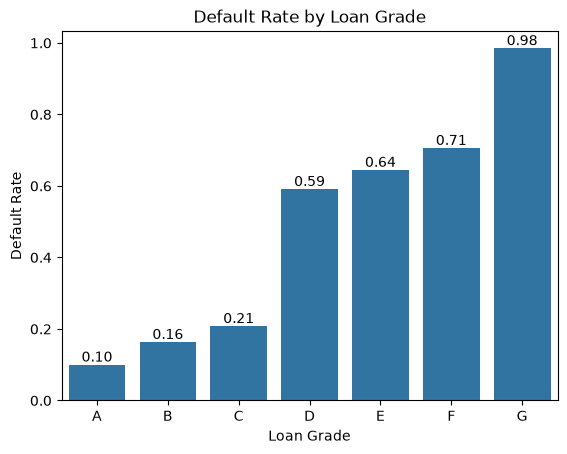

In [66]:
ax = sns.barplot(x=default_by_grade.index, y=default_by_grade.values)
ax.bar_label(ax.containers[0], fmt='%.2f')
plt.savefig("../images/default_rate_by_grade.png", bbox_inches='tight')
plt.title("Default Rate by Loan Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Default Rate")


In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           32581 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               32581 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [74]:
Sorted_columns=pd.DataFrame({ 
    'Candidate one-hot encoding':['loan_intent','person_home_ownership'],
    'Candidate simple binary mappin':['cb_person_default_on_file ',''],
    'Candidate ordinal encoding':['loan_grade','']})
print(Sorted_columns)

  Candidate one-hot encoding Candidate simple binary mappin  \
0                loan_intent     cb_person_default_on_file    
1      person_home_ownership                                  

  Candidate ordinal encoding  
0                 loan_grade  
1                             


df['cb_person_default_on_file'] = df['cb_person_default_on_file'].apply(lambda p: 1 if p == 'Y' else 0)

In [81]:
df['cb_person_default_on_file'] = pd.read_csv("../data/credit_risk_dataset.csv")['cb_person_default_on_file']

In [82]:
df['cb_person_default_on_file'].unique()


<StringArray>
['Y', 'N']
Length: 2, dtype: str

In [83]:
E={'Y':1, 'N':0}
df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map(E)
df['cb_person_default_on_file'].unique()


array([1, 0])

In [84]:
N={'A':0, 'B':1, 'C':2, 'D':3, 'E':4, 'F':5, 'G':6}
df['loan_grade'] = df['loan_grade'].map(N)
df['loan_grade'].unique()

array([3, 1, 2, 0, 4, 5, 6])